In [45]:
#3rd lab

import seaborn as sns
import matplotlib.pyplot as plt
import numpy as np
from sklearn.linear_model import LinearRegression
from sklearn.neighbors import KNeighborsRegressor


df = sns.load_dataset('tips')

In [3]:
df.head()

,total_bill,tip,sex,smoker,day,time,size
0,16.99,1.01,Female,No,Sun,Dinner,2
1,10.34,1.66,Male,No,Sun,Dinner,3
2,21.01,3.50,Male,No,Sun,Dinner,3
3,23.68,3.31,Male,No,Sun,Dinner,2
4,24.59,3.61,Female,No,Sun,Dinner,4


In [4]:
weekends = df[df['day'].isin(['Sat', 'Sun'])]
weekends.head()

,total_bill,tip,sex,smoker,day,time,size
0,16.99,1.01,Female,No,Sun,Dinner,2
1,10.34,1.66,Male,No,Sun,Dinner,3
2,21.01,3.50,Male,No,Sun,Dinner,3
3,23.68,3.31,Male,No,Sun,Dinner,2
4,24.59,3.61,Female,No,Sun,Dinner,4


In [7]:
weekdays = df[-df['day'].isin(['Sat', 'Sun'])]
weekdays.head()

,total_bill,tip,sex,smoker,day,time,size
77,27.20,4.00,Male,No,Thur,Lunch,4
78,22.76,3.00,Male,No,Thur,Lunch,2
79,17.29,2.71,Male,No,Thur,Lunch,2
80,19.44,3.00,Male,Yes,Thur,Lunch,2
81,16.66,3.40,Male,No,Thur,Lunch,2


In [9]:
df.isnull().sum()

total_bill    0
tip           0
sex           0
smoker        0
day           0
time          0
size          0
dtype: int64

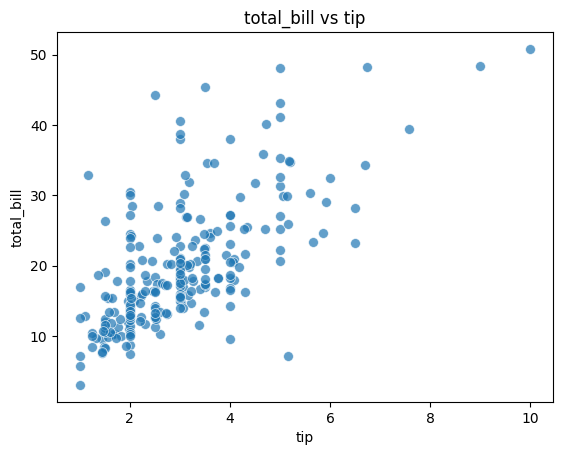

In [16]:
sns.scatterplot(x = 'tip', y = 'total_bill', data = df, alpha = 0.7, s = 50)
plt.title('total_bill vs tip')
plt.show()

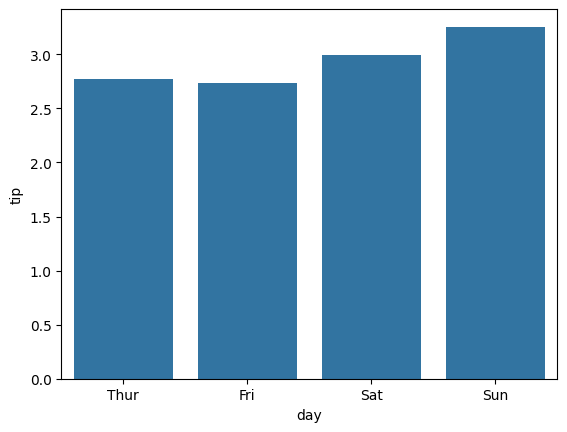

In [21]:
avg_tip_by_day = df.groupby('day', observed = False)['tip'].mean().reset_index()
sns.barplot(x = 'day', y = 'tip', data = avg_tip_by_day)
plt.show()

<Axes: xlabel='tip', ylabel='Count'>

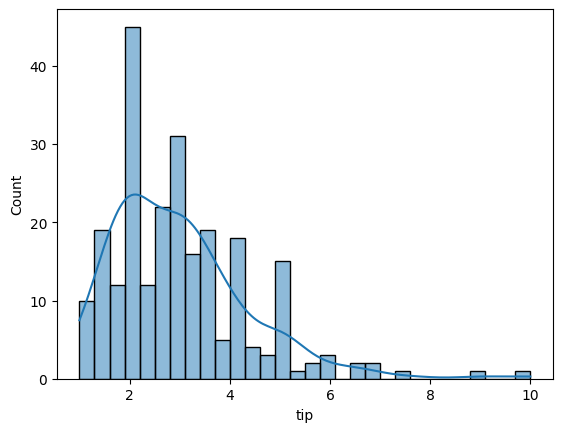

In [25]:
sns.histplot(df['tip'], kde = True, bins = 30)

In [27]:
#4th lab


In [77]:
df.describe()

,total_bill,tip,size
count,244.000000,244.000000,244.000000
mean,19.785943,2.998279,2.569672
std,8.902412,1.383638,0.951100
min,3.070000,1.000000,1.000000
25%,13.347500,2.000000,2.000000
50%,17.795000,2.900000,2.000000
75%,24.127500,3.562500,3.000000
max,50.810000,10.000000,6.000000


In [32]:
df.info

<bound method DataFrame.info of      total_bill   tip     sex smoker   day    time  size
0         16.99  1.01  Female     No   Sun  Dinner     2
1         10.34  1.66    Male     No   Sun  Dinner     3
2         21.01  3.50    Male     No   Sun  Dinner     3
3         23.68  3.31    Male     No   Sun  Dinner     2
4         24.59  3.61  Female     No   Sun  Dinner     4
..          ...   ...     ...    ...   ...     ...   ...
239       29.03  5.92    Male     No   Sat  Dinner     3
240       27.18  2.00  Female    Yes   Sat  Dinner     2
241       22.67  2.00    Male    Yes   Sat  Dinner     2
242       17.82  1.75    Male     No   Sat  Dinner     2
243       18.78  3.00  Female     No  Thur  Dinner     2

[244 rows x 7 columns]>

In [71]:
#linear regression model

X = df['total_bill']
y = df['tip']

X = X.values.reshape(-1,1)
y = y.values

print(X.shape)
print(y.shape)

(244, 1)
(244,)


In [72]:
model = LinearRegression()

model.fit(X, y)
print(model.coef_)
print(model.intercept_)

[0.10502452]
0.920269613554674


In [73]:
y_pred = model.predict(X)

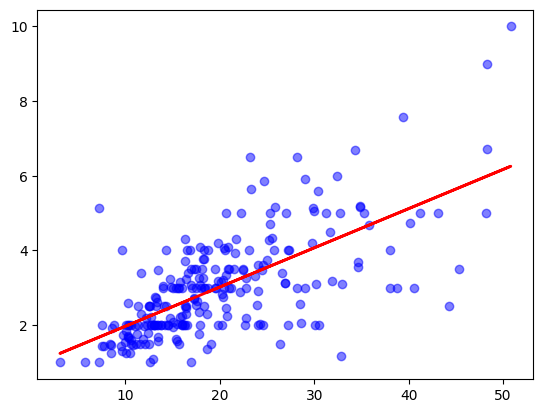

In [74]:
plt.scatter(X, y, color = 'blue', alpha = 0.5)
plt.plot(X, y_pred, color = 'red', linewidth = 2)
plt.show()

In [75]:
y_new = model.predict([[37000]])
y_new

array([3886.82741283])

In [80]:
knn_model = KNeighborsRegressor(n_neighbors = 3)
knn_model.fit(X, y)
y_pred = knn_model.predict(X)

In [81]:
y_new = knn_model.predict([[37000]])
y_new

array([8.57666667])

In [ ]:
knn_model = 